# Steering Tryout

In this notebook I will play around with steering to see and measure the impact and potential side effects.

Twenty sentence pairs, identical except for the sentiment words, so only sentiment should end up in the direction.

In [1]:
# Setup: GPT-2 small as in the other notebooks, plus the sentence pairs that define the concept.
# Minimal pairs, so topic, length and syntax cancel in the difference of means.
# Expectation: 20 per set, about 8 tokens on average, both sets the same length.
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2", device="mps")
torch.manual_seed(0)

pairs = [
    ("The movie was absolutely wonderful.", "The movie was absolutely terrible."),
    ("I loved every minute of the show.", "I hated every minute of the show."),
    ("The food at that place was delicious.", "The food at that place was disgusting."),
    ("What a fantastic day this has been.", "What a horrible day this has been."),
    ("Her new book is a delight to read.", "Her new book is a chore to read."),
    ("The hotel room was clean and cozy.", "The hotel room was dirty and cramped."),
    ("This is the best coffee I have ever had.", "This is the worst coffee I have ever had."),
    ("The concert last night was amazing.", "The concert last night was awful."),
    ("Our trip to the coast was perfect.", "Our trip to the coast was miserable."),
    ("The service here is friendly and quick.", "The service here is rude and slow."),
    ("I am so happy with how this turned out.", "I am so disappointed with how this turned out."),
    ("The garden looks beautiful this spring.", "The garden looks hideous this spring."),
    ("He gave a brilliant talk at the meeting.", "He gave a dull talk at the meeting."),
    ("The kids had a great time at the park.", "The kids had a rotten time at the park."),
    ("That was a lovely dinner with old friends.", "That was a painful dinner with old friends."),
    ("The new phone works smoothly.", "The new phone works poorly."),
    ("Everyone enjoyed the party last weekend.", "Everyone disliked the party last weekend."),
    ("The weather has been glorious all week.", "The weather has been dreadful all week."),
    ("The team played superbly in the final.", "The team played dismally in the final."),
    ("My first day at the new job was exciting.", "My first day at the new job was depressing."),
]
pos_sentences = [p for p, _ in pairs]
neg_sentences = [n for _, n in pairs]

def n_tokens(sentence):
    return model.to_tokens(sentence).shape[1] - 1  # to_tokens prepends BOS, which we never average over

for label, sentences in [("positive", pos_sentences), ("negative", neg_sentences)]:
    lengths = [n_tokens(s) for s in sentences]
    print(f"{label}: {len(sentences)} sentences, {sum(lengths) / len(lengths):.1f} tokens on average, "
          f"min {min(lengths)} max {max(lengths)}")


/Users/Brose/dev/private_repos/mechinterp_xai/.venv/lib/python3.13/site-packages/transformer_lens/config/hooked_transformer_config.py:354: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.13.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
positive: 20 sentences, 8.2 tokens on average, min 6 max 10
negative: 20 sentences, 8.2 tokens on average, min 6 max 10


Difference of means at layer 6. Reading check first: does the projection separate the sets? Leave-one-pair-out, so d is not graded on the sentences it was built from.

In [2]:
# Direction: mean residual stream at blocks.6.hook_resid_pre per sentence, BOS dropped (attention
# sink, norm ~3000), d = mean(pos) - mean(neg) at unit length. Reading check leave-one-pair-out,
# since in-sample the means differ by construction. Expectation: norm 100-200, all 20 pairs ordered.
LAYER = 6

def sentence_resid(sentence, layer):
    # [positions, d_model] at the layer input, BOS dropped
    name = f"blocks.{layer}.hook_resid_pre"
    _, cache = model.run_with_cache(model.to_tokens(sentence), names_filter=name)
    return cache[name][0, 1:]

def direction(pos, neg):
    diff = pos.mean(0) - neg.mean(0)
    return diff / diff.norm(), diff.norm().item()

pos_resid = [sentence_resid(s, LAYER) for s in pos_sentences]
neg_resid = [sentence_resid(s, LAYER) for s in neg_sentences]
pos_acts = torch.stack([r.mean(0) for r in pos_resid])  # [20, d_model], one vector per sentence
neg_acts = torch.stack([r.mean(0) for r in neg_resid])
resid_norm = torch.cat(pos_resid + neg_resid).norm(dim=-1).mean().item()

d, gap = direction(pos_acts, neg_acts)
print(f"layer {LAYER}: per-position residual norm {resid_norm:.1f}, |mean(pos) - mean(neg)| = {gap:.2f}")

pos_proj, neg_proj = pos_acts @ d, neg_acts @ d
print(f"in-sample projection: positive {pos_proj.min():.2f} .. {pos_proj.max():.2f}, "
      f"negative {neg_proj.min():.2f} .. {neg_proj.max():.2f}")

# leave-one-pair-out: does d built without pair i still put pair i in the right order?
margins = []
for i in range(len(pairs)):
    keep = [j for j in range(len(pairs)) if j != i]
    d_i, _ = direction(pos_acts[keep], neg_acts[keep])
    margins.append((pos_acts[i] @ d_i - neg_acts[i] @ d_i).item())
margins = torch.tensor(margins)
print(f"held-out margin pos - neg per pair: mean {margins.mean():.2f}, min {margins.min():.2f}, "
      f"{(margins > 0).sum().item()} of {len(pairs)} pairs ordered correctly")


layer 6: per-position residual norm 83.0, |mean(pos) - mean(neg)| = 6.21
in-sample projection: positive -0.47 .. 4.03, negative -6.30 .. -1.76
held-out margin pos - neg per pair: mean 5.64, min 3.29, 20 of 20 pairs ordered correctly


Reading works: 20 of 20 held-out pairs ordered correctly, margin 5.6 vs 6.2 in-sample. Within-set spread (~4.5) is almost as large as the gap, so d carries more than sentiment. Norm 83, not the 100-200 I expected.

The metric: neutral prompts ending before an adjective, logit difference of eight positive vs eight negative adjectives, none from the sentence pairs. Baseline first.

In [3]:
# Metric: at the last position of each neutral prompt, mean logit of eight positive adjectives minus
# eight negative ones, deliberately not the words d was built from. One forward pass, no generation.
# Expectation: baseline within -1 .. +1 per prompt, top-5 next tokens mostly not adjectives.
prompts = [
    "The movie was", "I thought the food was", "Overall, the hotel was", "My day at work was",
    "The concert last night was", "Honestly, the book was", "The weather today is",
    "The service at the restaurant was", "The game yesterday was", "Her presentation was",
]
pos_words = ["good", "great", "excellent", "nice", "enjoyable", "pleasant", "impressive", "outstanding"]
neg_words = ["bad", "boring", "poor", "disappointing", "unpleasant", "mediocre", "lousy", "pathetic"]
pos_ids = torch.tensor([model.to_single_token(" " + w) for w in pos_words]).to("mps")
neg_ids = torch.tensor([model.to_single_token(" " + w) for w in neg_words]).to("mps")

def last_logits(prompt, fwd_hooks=()):
    logits = model.run_with_hooks(model.to_tokens(prompt), fwd_hooks=list(fwd_hooks))
    return logits[0, -1]

def logit_diff(fwd_hooks=()):
    # one number per prompt: positive adjectives minus negative ones at the next-token position
    return torch.tensor([(l[pos_ids].mean() - l[neg_ids].mean()).item()
                         for l in (last_logits(p, fwd_hooks) for p in prompts)])

baseline = logit_diff()
for p, b in zip(prompts, baseline):
    print(f"{b:6.2f}  {p}")
print(f"baseline logit difference: mean {baseline.mean():.2f}, min {baseline.min():.2f}, max {baseline.max():.2f}")

for p in prompts[:2]:
    top = last_logits(p).topk(5).indices
    print(f"{p!r} -> {model.to_str_tokens(top)}")


  1.60  The movie was
  2.18  I thought the food was
  3.90  Overall, the hotel was
  0.46  My day at work was
  1.98  The concert last night was
  1.36  Honestly, the book was
  1.56  The weather today is
  1.71  The service at the restaurant was
  1.75  The game yesterday was
  2.39  Her presentation was
baseline logit difference: mean 1.89, min 0.46, max 3.90
'The movie was' -> [' released', ' directed', ' shot', ' originally', ' made']
'I thought the food was' -> [' good', ' delicious', ' pretty', ' great', ' amazing']


The model leans positive already (mean 1.9, hotels 3.9), so the sweep is read as change against baseline. For "The movie was" no adjective is even in the top 5.

Now the intervention: add α·d at layer 6 on all positions except BOS, dose c as a fraction of the residual norm (83). The natural gap between the sets is 0.075 on this scale.

In [4]:
# Dose sweep: alpha * d added at blocks.6.hook_resid_pre on every position except BOS, alpha as a
# fraction c of the mean residual norm (83) so doses compare across layers. Expectation: monotone
# in c, visible from c = 0.1, saturating or breaking beyond 0.5; the top-5 shows whether the prompt
# still gets a sensible continuation.
def add_direction(vector, alpha):
    def hook(resid, hook):
        resid[:, 1:] += alpha * vector  # leave BOS alone, it is the attention sink
        return resid
    return hook

coefficients = [-1, -0.75, -0.5, -0.35, -0.25, -0.15, -0.1, -0.05, 0,
                0.05, 0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 1]

def sweep_logit_diff(vector, layer, norm):
    name = f"blocks.{layer}.hook_resid_pre"
    return torch.stack([logit_diff([(name, add_direction(vector, c * norm))]).mean()
                        for c in coefficients])

curve_d = sweep_logit_diff(d, LAYER, resid_norm)
print("    c   logit diff   vs baseline")
for c, v in zip(coefficients, curve_d):
    print(f"{c:6.2f}   {v:8.2f}   {v - baseline.mean():+8.2f}")

for c in (-0.5, -0.15, 0.15, 0.5):
    top = last_logits("The movie was", [(f"blocks.{LAYER}.hook_resid_pre", add_direction(d, c * resid_norm))]).topk(5).indices
    print(f"c = {c:5.2f}  'The movie was' -> {model.to_str_tokens(top)}")


    c   logit diff   vs baseline
 -1.00      -0.86      -2.75
 -0.75      -0.88      -2.77
 -0.50      -0.64      -2.53
 -0.35      -0.36      -2.25
 -0.25      -0.04      -1.93
 -0.15       0.35      -1.54
 -0.10       0.57      -1.32
 -0.05       1.04      -0.85
  0.00       1.89      +0.00
  0.05       2.72      +0.83
  0.10       3.41      +1.53
  0.15       4.02      +2.13
  0.25       5.05      +3.16
  0.35       5.84      +3.96
  0.50       6.63      +4.74
  0.75       7.15      +5.26
  1.00       7.24      +5.35
c = -0.50  'The movie was' -> [' released', ' directed', ' set', ' written', ' a']
c = -0.15  'The movie was' -> [' released', ' directed', ' originally', ' made', ' a']
c =  0.15  'The movie was' -> [' released', ' directed', ' shot', ' filmed', ' made']
c =  0.50  'The movie was' -> [' filmed', ' a', ' shot', ' presented', ' made']


Matplotlib is building the font cache; this may take a moment.


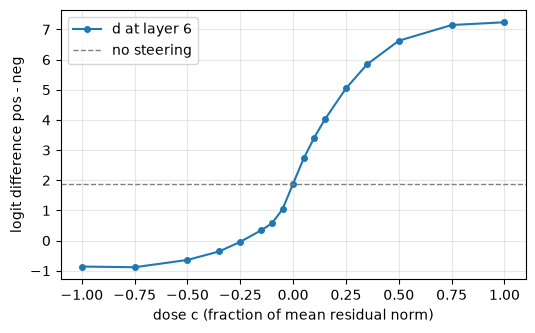

In [5]:
# Plot helper, reused for the controls: one line per curve, unsteered baseline dashed.
import matplotlib.pyplot as plt

def plot_curves(curves, ylabel, baseline_value=None):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for label, values in curves.items():
        ax.plot(coefficients, values.tolist(), marker="o", ms=4, label=label)
    if baseline_value is not None:
        ax.axhline(baseline_value, color="grey", lw=1, ls="--", label="no steering")
    ax.set_xlabel("dose c (fraction of mean residual norm)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

plot_curves({"d at layer 6": curve_d}, "logit difference pos - neg", baseline.mean().item())


S-curve, steepest around zero, flat from c = 0.5. Asymmetric: +5.4 up, −2.8 down. The top-5 for "The movie was" never change, so the metric moves while the actual predictions do not. Plateau guess: LayerNorm in later layers, not tested.

Side effect next: loss on factual sentences under the same doses.

baseline loss on neutral sentences: 3.99
    c   logit diff    loss   increase
 -1.00      -0.86    5.35    +1.36
 -0.75      -0.88    4.78    +0.79
 -0.50      -0.64    4.28    +0.29
 -0.35      -0.36    4.07    +0.08
 -0.25      -0.04    4.00    +0.01
 -0.15       0.35    3.97    -0.02
 -0.10       0.57    3.97    -0.02
 -0.05       1.04    3.98    -0.01
  0.00       1.89    3.99    +0.00
  0.05       2.72    4.01    +0.02
  0.10       3.41    4.04    +0.05
  0.15       4.02    4.08    +0.09
  0.25       5.05    4.18    +0.19
  0.35       5.84    4.34    +0.35
  0.50       6.63    4.68    +0.69
  0.75       7.15    5.35    +1.36
  1.00       7.24    5.99    +2.00


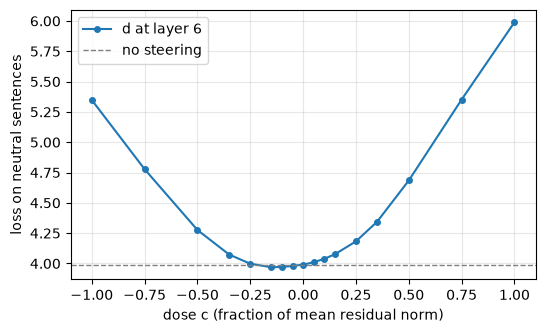

In [6]:
# Side effect: next-token loss on neutral factual sentences under the same doses, nothing about
# sentiment in them. Expectation: baseline 3.5-4.5 nats, no change for |c| <= 0.1, clearly worse
# from 0.35, and the metric plateau above 0.5 coincides with a loss that has already gone up.
neutral_sentences = [
    "The train to Hamburg leaves from platform four every hour.",
    "Water boils at one hundred degrees Celsius at sea level.",
    "The library closes at eight on weekdays and at six on Saturdays.",
    "Copper conducts electricity better than aluminium.",
    "The meeting has been moved to the second floor conference room.",
    "Most of the city's buses run on natural gas.",
    "The recipe calls for two eggs and a cup of flour.",
    "The river flows north before it reaches the coast.",
    "Her office is next to the elevator on the third floor.",
    "The museum was built in the nineteenth century.",
]
neutral_tokens = [model.to_tokens(s) for s in neutral_sentences]

def neutral_loss(fwd_hooks=()):
    # mean next-token loss over all positions, averaged over the sentences
    return torch.tensor([model.run_with_hooks(t, return_type="loss", fwd_hooks=list(fwd_hooks)).item()
                         for t in neutral_tokens]).mean()

def sweep_loss(vector, layer, norm):
    name = f"blocks.{layer}.hook_resid_pre"
    return torch.stack([neutral_loss([(name, add_direction(vector, c * norm))]) for c in coefficients])

baseline_loss = neutral_loss()
loss_d = sweep_loss(d, LAYER, resid_norm)
print(f"baseline loss on neutral sentences: {baseline_loss:.2f}")
print("    c   logit diff    loss   increase")
for c, v, l in zip(coefficients, curve_d, loss_d):
    print(f"{c:6.2f}   {v:8.2f}   {l:5.2f}   {l - baseline_loss:+6.2f}")
plot_curves({"d at layer 6": loss_d}, "loss on neutral sentences", baseline_loss.item())


Parabola around zero, positive doses cost more (+0.69 vs +0.29 at |c| = 0.5). Up to c = 0.25 three logits for 0.2 nats, beyond that the plateau is bought with rising loss: degradation, not agreement.

Controls: random unit vector at layer 6, same doses; d drawn and added at layers 2 and 10.

cos(random, d) = 0.003
layer  2: residual norm 59.1, gap 2.94, held-out 20/20, cos(d_2, d_6) = 0.791
layer 10: residual norm 165.3, gap 12.95, held-out 20/20, cos(d_10, d_6) = 0.750

change in logit difference / loss increase, both vs baseline
    c          d layer 6  random layer 6       d layer 2      d layer 10
 -1.00     -2.75/+1.36   -0.88/+1.77   -2.02/+2.12   -9.56/+1.46 
 -0.50     -2.53/+0.29   -0.42/+0.48   -2.07/+0.48   -5.95/+0.37 
 -0.25     -1.93/+0.01   -0.04/+0.13   -1.28/+0.07   -3.70/+0.08 
 -0.10     -1.32/-0.02   +0.03/+0.03   -0.57/+0.02   -1.81/+0.02 
  0.10     +1.53/+0.05   -0.06/-0.00   +0.63/+0.00   +2.02/+0.02 
  0.25     +3.16/+0.19   -0.19/+0.05   +1.48/+0.13   +4.80/+0.16 
  0.50     +4.74/+0.69   -0.30/+0.34   +2.07/+0.93   +8.40/+0.63 
  1.00     +5.35/+2.00   -0.03/+1.51   +1.48/+2.46  +12.82/+1.81 


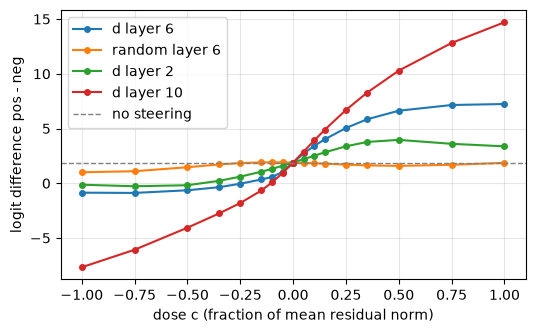

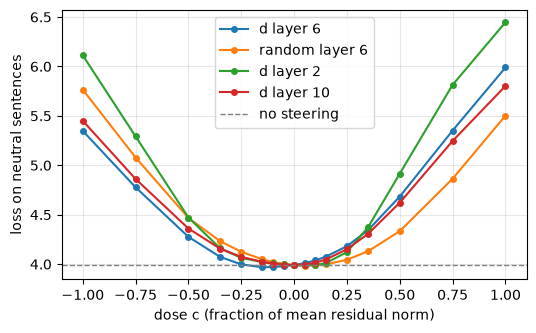

In [7]:
# Controls: norm-matched random vector at layer 6, and d drawn and added at layers 2 and 10, each
# with its own residual norm as dose unit. Expectation: random flat on the metric, less loss than d;
# layer 2 weaker; layer 10 stronger per dose at less loss; cos(d_l, d_6) well below 1.
torch.manual_seed(1)
r = torch.randn(model.cfg.d_model)  # drawn on CPU so the seed gives the same vector on any device
r = (r / r.norm()).to("mps")
print(f"cos(random, d) = {(r @ d):.3f}")

def held_out_pairs(pos, neg):
    # same leave-one-pair-out count as in the reading check at layer 6
    ok = 0
    for i in range(len(pos)):
        keep = [j for j in range(len(pos)) if j != i]
        d_i, _ = direction(pos[keep], neg[keep])
        ok += int((pos[i] @ d_i - neg[i] @ d_i) > 0)
    return ok

conditions = {"random layer 6": (r, LAYER, resid_norm)}
for layer in (2, 10):
    p = [sentence_resid(s, layer) for s in pos_sentences]
    n = [sentence_resid(s, layer) for s in neg_sentences]
    p_acts, n_acts = torch.stack([x.mean(0) for x in p]), torch.stack([x.mean(0) for x in n])
    d_l, gap_l = direction(p_acts, n_acts)
    norm_l = torch.cat(p + n).norm(dim=-1).mean().item()
    print(f"layer {layer:2d}: residual norm {norm_l:.1f}, gap {gap_l:.2f}, "
          f"held-out {held_out_pairs(p_acts, n_acts)}/20, cos(d_{layer}, d_6) = {(d_l @ d):.3f}")
    conditions[f"d layer {layer}"] = (d_l, layer, norm_l)

metric_curves = {"d layer 6": curve_d}
loss_curves = {"d layer 6": loss_d}
for label, args in conditions.items():
    metric_curves[label] = sweep_logit_diff(*args)
    loss_curves[label] = sweep_loss(*args)

show = [-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1]
print("\nchange in logit difference / loss increase, both vs baseline")
print("    c   " + "".join(f"{label:>16s}" for label in metric_curves))
for c in show:
    i = coefficients.index(c)
    row = "".join(f"{metric_curves[l][i] - baseline.mean():+7.2f}/{loss_curves[l][i] - baseline_loss:+5.2f} "
                  for l in metric_curves)
    print(f"{c:6.2f}   {row}")
plot_curves(metric_curves, "logit difference pos - neg", baseline.mean().item())
plot_curves(loss_curves, "loss on neutral sentences", baseline_loss.item())


Random is flat on the metric (within 0.3) but costs loss too: 1.5 nats at c = 1 against 2.0 for d, and on the negative side more than d. At full dose the size of the intervention explains most of the damage, at c = 0.5 the direction still matters. Layer 10 roughly doubles the effect at the same loss and keeps growing where layer 6 is flat; layer 2 is the worst deal and turns non-monotone at c = 1. The three directions correlate at 0.75-0.79: same concept, not the same vector.

## What I take from this

A difference-of-means direction from 20 minimal pairs reads sentiment at every layer I tried, 20 of 20 held-out. Writing it back works dose-dependently, but the curve saturates where the loss takes off, and the useful window at layer 6 is roughly |c| < 0.25: three logits for a fifth of a nat. The layer sets the exchange rate, layer 10 gets twice the shift for the same damage, and the random control shows that at large doses a good part of that damage is just the norm added, not the sentiment.

The metric is the weak spot: it moves by up to 13 logits while the top-5 continuations at layer 6 barely change, because it compares two adjective lists the model was not about to say anyway. Whether steered text reads differently is a separate question I did not measure. Ten prompts, ten sentences, one random draw: orientation, not statistics.